This is an example notebook showing how to use ntwk_fit module to do DCM fitting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

# Import fitting module
from ntwk_fit import *

In [2]:
# Create a Network instance from an s2p measurement file
res_6G763 = rf.Network('res_6G763_ntwk.s2p')
res_6G763.frequency.unit = 'GHz'

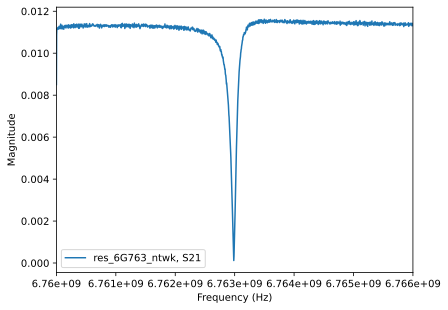

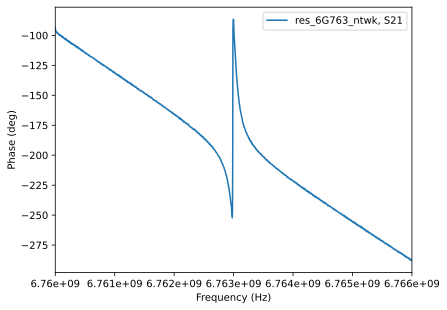

In [3]:
# Plot the magnitude and phase
res_6G763 = rf.Network('res_6G763_ntwk.s2p')
res_6G763.plot_s_mag(1,0)
plt.show()
res_6G763.plot_s_deg_unwrap(1,0)
plt.show()

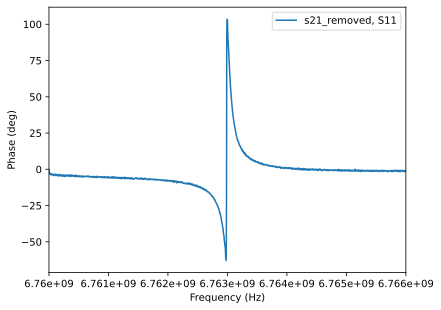

In [4]:
# Use the last 100 points to determine the electrical delay, and remove it.
removed_6G763 = remove_delay(res_6G763, 'absorption', L = -100, R = -1)
removed_6G763.plot_s_deg_unwrap()

# Note the legend shows 'S11', but it is because the network is only 1-port after processing

In [5]:
# Set a desired frequency range for Diameter Correction Method fitting
fit_range = '6.7625-6.7635GHz'
DCM_6G763, param = DCM_fit(removed_6G763[fit_range])
param

{'f0': 6763005007.479664,
 'Q_tot': 42460.16889585377,
 'Q_ext': 43221.85333677319,
 'amp': 0.011279160677156813,
 'phi': -0.20594571132701334,
 'tau': -5.664042951856965e-08,
 'phase': -0.022706753282322283,
 'Q_int': 2409406.1714795837}

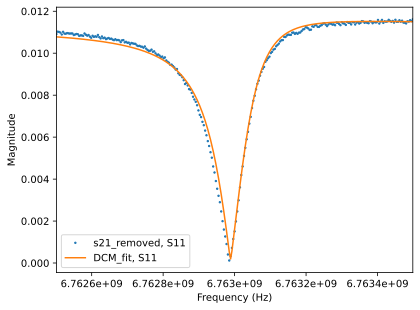

In [6]:
# Plot fitting results
removed_6G763[fit_range].plot_s_mag(ls='', marker = '.', ms=3)
DCM_6G763.plot_s_mag()

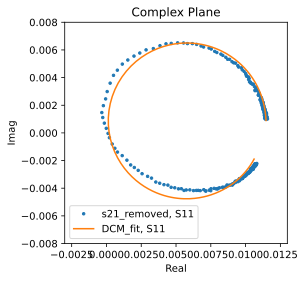

In [7]:
plt.figure(figsize = (4,4))
removed_6G763[fit_range].plot_s_complex(ls='', marker = '.', ms=5)
DCM_6G763.plot_s_complex()
plt.ylim(-0.008,0.008)
plt.xlim(-0.008+0.005,0.008+0.005)
plt.show()